In [ ]:
# Cell 0: Imports + device

import os, glob, json, math, pickle, random, time
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

DEVICE: cpu


In [ ]:
# Cell 1: Mount Drive

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# Cell 2: Paths

DATASET_PATH = "/content/drive/MyDrive/AIAGENT_FINAL/obtain_diamond_v3_fixdone"
SEQ_DIR      = "/content/drive/MyDrive/AIAGENT_FINAL/outputs_sequences"
SWEEP_ROOT   = "/content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/overlap_sweep"
METRICS_DIR  = "/content/drive/MyDrive/AIAGENT_FINAL/outputs/metrics"
os.makedirs(METRICS_DIR, exist_ok=True)

EXPERIMENT_INDEX_PATH = os.path.join(SWEEP_ROOT, "experiment_index.json")
ACTION_RESULTS_PATH   = os.path.join(METRICS_DIR, "action_agreement.json")
ACTION_BANK_PATH      = os.path.join(METRICS_DIR, "candidate_action_bank.npz")

train_pkl = os.path.join(SEQ_DIR, "train_sequences.pkl")
test_pkl  = os.path.join(SEQ_DIR, "test_sequences.pkl")
meta_json = os.path.join(SEQ_DIR, "sequences_meta.json")
norm_path = os.path.join(SEQ_DIR, "global_train_state_norm_stats.npz")

with open(train_pkl, "rb") as f:
    train_seqs = pickle.load(f)
with open(test_pkl, "rb") as f:
    test_seqs = pickle.load(f)
with open(meta_json, "r") as f:
    seq_meta = json.load(f)
with open(EXPERIMENT_INDEX_PATH, "r") as f:
    experiment_index = json.load(f)

z = np.load(norm_path)
state_mean = z["state_mean"].astype(np.float32)
state_std  = z["state_std"].astype(np.float32)

SEQ_LEN = int(seq_meta["seq_len"])
BURN_IN = int(seq_meta["burn_in"])
train_shards = list(seq_meta["splits"]["train_shards"])

print("Loaded train/test sequences:", len(train_seqs), len(test_seqs))
print("Num overlap runs:", len(experiment_index["runs"]))

Loaded train/test sequences: 200000 149650
Num overlap runs: 15


In [ ]:
# Cell 3: Config

STEP_OFFSET = 0
TEST_CAP = None
BATCH_SIZE = 128 if DEVICE.type == "cuda" else 32
NUM_WORKERS = 0
SEED_EVAL = 2027

# candidate-action planning settings
CANDIDATE_K = 16
ACTION_BANK_MAX = 512
ACTION_ROUND_DECIMALS = 4

# NEW: reward-planning proxy settings
PLAN_HORIZON = 5
USE_LOG_REWARD_SCORE = True

assert CANDIDATE_K >= 2
assert STEP_OFFSET < SEQ_LEN
assert PLAN_HORIZON >= 1
assert STEP_OFFSET + PLAN_HORIZON <= SEQ_LEN

print("STEP_OFFSET:", STEP_OFFSET)
print("TEST_CAP:", TEST_CAP)
print("BATCH_SIZE:", BATCH_SIZE)
print("CANDIDATE_K:", CANDIDATE_K)
print("ACTION_BANK_MAX:", ACTION_BANK_MAX)
print("PLAN_HORIZON:", PLAN_HORIZON)
print("USE_LOG_REWARD_SCORE:", USE_LOG_REWARD_SCORE)

STEP_OFFSET: 0
TEST_CAP: None
BATCH_SIZE: 32
CANDIDATE_K: 16
ACTION_BANK_MAX: 512
PLAN_HORIZON: 5
USE_LOG_REWARD_SCORE: True


In [ ]:
# Cell 4: Shard path map

shards = sorted(glob.glob(os.path.join(DATASET_PATH, "shard_*.npz")))
path_map = {os.path.basename(p): p for p in shards}
assert len(path_map) == 30, f"Expected 30 shards, got {len(path_map)}"

def check_seq_refs(seqs, name):
    names = {s["shard"] for s in seqs}
    missing = sorted(list(names - set(path_map.keys())))
    assert len(missing) == 0, f"{name} references missing shards: {missing[:5]}"

check_seq_refs(train_seqs, "train")
check_seq_refs(test_seqs, "test")
print("Shard references OK.")

Shard references OK.


In [ ]:
# Cell 5: Shared normalized shard cache

_SHARD_CACHE = {}

def load_shard_cached(shard_name: str):
    if shard_name in _SHARD_CACHE:
        return _SHARD_CACHE[shard_name]

    p = path_map[shard_name]
    with np.load(p) as d:
        obs = d["obs"].astype(np.float32)
        mainhand = d["mainhand"].astype(np.float32)
        action = d["action"].astype(np.float32)
        reward = d["reward"].astype(np.float32)
        done = d["done"].astype(np.bool_)

    state_raw = np.concatenate([obs, mainhand], axis=1)   # (N, 28)
    state = (state_raw - state_mean) / (state_std + 1e-8)

    _SHARD_CACHE[shard_name] = (state, action, reward, done)
    return _SHARD_CACHE[shard_name]

In [ ]:
# Cell 6: Dataset / loader

class SequenceDataset(Dataset):
    """
    Returns:
      s:   (L+1, 28) float32 states
      a:   (L,   15) float32 actions
      r:   (L,)      float32 rewards
      cont:(L,)      float32 continuation = 1 - done[t]
    """
    def __init__(self, seqs, seq_len=50):
        self.seqs = seqs
        self.L = seq_len

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        rec = self.seqs[idx]
        shard = rec["shard"]
        t0 = int(rec["t0"])
        L  = int(rec["length"])
        assert L == self.L

        state, action, reward, done = load_shard_cached(shard)

        s = state[t0:t0+L+1]
        a = action[t0:t0+L]
        r = reward[t0:t0+L]
        cont = 1.0 - done[t0:t0+L].astype(np.float32)

        return (
            torch.from_numpy(s),
            torch.from_numpy(a),
            torch.from_numpy(r),
            torch.from_numpy(cont),
        )

def make_loader(seqs, batch_size, shuffle=False, cap=None, seed=0):
    if cap is not None and len(seqs) > cap:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(seqs), size=cap, replace=False)
        idx = np.sort(idx)
        seqs = [seqs[i] for i in idx]

    ds = SequenceDataset(seqs, seq_len=SEQ_LEN)
    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        drop_last=False,
    )
    return dl, len(ds)

In [ ]:
# Cell 7: RSSM model definitions (same as Notebook 5 / 6)

def _init_layer(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

class Encoder(nn.Module):
    def __init__(self, state_dim=28, hidden=256, embed_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, embed_dim), nn.ReLU(),
        )
        self.apply(_init_layer)

    def forward(self, s):
        return self.net(s)

class RSSM(nn.Module):
    def __init__(self, action_dim=15, deter_dim=256, stoch_dim=32, hidden=256, min_std=0.1):
        super().__init__()
        self.deter_dim = deter_dim
        self.stoch_dim = stoch_dim
        self.min_std = min_std

        self.gru = nn.GRUCell(stoch_dim + action_dim, deter_dim)

        self.prior_net = nn.Sequential(
            nn.Linear(deter_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, 2 * stoch_dim),
        )

        self.post_net = nn.Sequential(
            nn.Linear(deter_dim + hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 2 * stoch_dim),
        )
        self.apply(_init_layer)

    def init_state(self, batch_size):
        h = torch.zeros(batch_size, self.deter_dim, device=DEVICE)
        z = torch.zeros(batch_size, self.stoch_dim, device=DEVICE)
        return h, z

    def _dist(self, params):
        mu, std = torch.chunk(params, 2, dim=-1)
        std = F.softplus(std) + self.min_std
        return mu, std

    def deter_step(self, h, z, a):
        x = torch.cat([z, a], dim=-1)
        h = self.gru(x, h)
        return h

    def prior(self, h):
        params = self.prior_net(h)
        mu, std = self._dist(params)
        return mu, std

    def posterior(self, h, embed):
        x = torch.cat([h, embed], dim=-1)
        params = self.post_net(x)
        mu, std = self._dist(params)
        return mu, std

    def sample(self, mu, std):
        eps = torch.randn_like(mu)
        return mu + eps * std

class Decoder(nn.Module):
    def __init__(self, deter_dim=256, stoch_dim=32, hidden=256, state_dim=28):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(deter_dim + stoch_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, state_dim),
        )
        self.apply(_init_layer)

    def forward(self, h, z):
        x = torch.cat([h, z], dim=-1)
        return self.net(x)

class RewardHead(nn.Module):
    def __init__(self, deter_dim=256, stoch_dim=32, hidden=256):
        super().__init__()
        self.base = nn.Sequential(
            nn.Linear(deter_dim + stoch_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.r_out = nn.Linear(hidden, 1)
        self.m_out = nn.Linear(hidden, 1)
        self.apply(_init_layer)

    def forward(self, h, z):
        x = torch.cat([h, z], dim=-1)
        f = self.base(x)
        r = self.r_out(f).squeeze(-1)
        m = self.m_out(f).squeeze(-1)
        return r, m

class ContHead(nn.Module):
    def __init__(self, deter_dim=256, stoch_dim=32, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(deter_dim + stoch_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )
        self.apply(_init_layer)

    def forward(self, h, z):
        x = torch.cat([h, z], dim=-1)
        return self.net(x).squeeze(-1)

class DreamerWorldModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.enc = Encoder(
            state_dim=cfg["state_dim"],
            hidden=cfg["hidden"],
            embed_dim=cfg["hidden"],
        )
        self.rssm = RSSM(
            action_dim=cfg["action_dim"],
            deter_dim=cfg["deter_dim"],
            stoch_dim=cfg["stoch_dim"],
            hidden=cfg["hidden"],
            min_std=cfg["min_std"],
        )
        self.dec = Decoder(
            deter_dim=cfg["deter_dim"],
            stoch_dim=cfg["stoch_dim"],
            hidden=cfg["hidden"],
            state_dim=cfg["state_dim"],
        )
        self.rew = RewardHead(
            deter_dim=cfg["deter_dim"],
            stoch_dim=cfg["stoch_dim"],
            hidden=cfg["hidden"],
        )
        self.cont = ContHead(
            deter_dim=cfg["deter_dim"],
            stoch_dim=cfg["stoch_dim"],
            hidden=cfg["hidden"],
        )

In [ ]:
# Cell 8: Checkpoint loader

def load_world_model_from_ckpt(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    cfg = ckpt["cfg"]
    wm = DreamerWorldModel(cfg).to(DEVICE)
    wm.load_state_dict(ckpt["state_dict"])
    wm.eval()
    return wm, ckpt, cfg

In [ ]:
# Cell 9: Build empirical candidate action bank

def build_action_bank(train_shards, path_map, max_actions=512, round_decimals=4, seed=0):
    """
    Build a reproducible empirical candidate action bank from train shards.
    Deduplicate rounded action vectors, then subsample if too large.
    """
    all_actions = []
    for shard_name in train_shards:
        with np.load(path_map[shard_name]) as d:
            a = d["action"].astype(np.float32)
        all_actions.append(a)

    all_actions = np.concatenate(all_actions, axis=0)   # (N, 15)
    rounded = np.round(all_actions, decimals=round_decimals)
    unique = np.unique(rounded, axis=0)

    rng = np.random.default_rng(seed)
    if unique.shape[0] > max_actions:
        idx = rng.choice(unique.shape[0], size=max_actions, replace=False)
        unique = unique[np.sort(idx)]

    return unique.astype(np.float32)

if os.path.exists(ACTION_BANK_PATH):
    z = np.load(ACTION_BANK_PATH)
    action_bank = z["action_bank"].astype(np.float32)
    print("Loaded action bank from:", ACTION_BANK_PATH)
else:
    action_bank = build_action_bank(
        train_shards=train_shards,
        path_map=path_map,
        max_actions=ACTION_BANK_MAX,
        round_decimals=ACTION_ROUND_DECIMALS,
        seed=SEED_EVAL,
    )
    np.savez(ACTION_BANK_PATH, action_bank=action_bank)
    print("Built and saved action bank to:", ACTION_BANK_PATH)

print("Action bank shape:", action_bank.shape)
assert action_bank.shape[1] == 15

Built and saved action bank to: /content/drive/MyDrive/AIAGENT_FINAL/outputs/metrics/candidate_action_bank.npz
Action bank shape: (512, 15)


In [ ]:
# Cell 10: H-step cumulative-reward planning helper

@torch.no_grad()
def score_candidate_actions_hstep_reward(
    wm,
    s,
    a_hist,
    candidate_actions,
    step_offset=0,
    plan_horizon=5,
    use_log_reward_score=True
):
    """
    Score each candidate action by predicted cumulative reward over a short horizon.

    Procedure:
    - infer latent state at anchor s_t
    - apply candidate action at time t
    - for remaining horizon steps, continue with the ACTUAL future actions from dataset
    - sum predicted rewards

    Inputs:
      s: (B, L+1, state_dim)
      a_hist: (B, L, action_dim)
      candidate_actions: (B, K, action_dim)

    Returns:
      scores: (B, K)
    """
    B, Lp1, _ = s.shape
    L = Lp1 - 1
    K = candidate_actions.shape[1]

    assert step_offset + plan_horizon <= L

    # Encode anchor state
    emb = wm.enc(s[:, step_offset, :])

    # Infer latent state up to anchor
    h, z = wm.rssm.init_state(B)

    if step_offset > 0:
        emb_all = wm.enc(s[:, :step_offset, :].reshape(B * step_offset, -1)).reshape(B, step_offset, -1)
        for t in range(step_offset):
            mu_q, std_q = wm.rssm.posterior(h, emb_all[:, t, :])
            z = wm.rssm.sample(mu_q, std_q)
            h = wm.rssm.deter_step(h, z, a_hist[:, t, :])

    # Posterior at anchor state
    mu_q, std_q = wm.rssm.posterior(h, emb)
    z_anchor = mu_q      # deterministic mean for stable planning
    h_anchor = h

    # Tile for K candidates
    h_t = h_anchor.unsqueeze(1).repeat(1, K, 1).reshape(B * K, -1)
    z_t = z_anchor.unsqueeze(1).repeat(1, K, 1).reshape(B * K, -1)

    scores = torch.zeros(B * K, device=DEVICE)

    # Step 0: use candidate action
    a0 = candidate_actions.reshape(B * K, -1)
    h_t = wm.rssm.deter_step(h_t, z_t, a0)
    mu_p, std_p = wm.rssm.prior(h_t)
    z_t = mu_p
    r_hat, _ = wm.rew(h_t, z_t)
    scores += r_hat

    # Steps 1..H-1: continue with actual future actions
    for j in range(1, plan_horizon):
        a_j = a_hist[:, step_offset + j, :]                    # (B, A)
        a_j = a_j.unsqueeze(1).repeat(1, K, 1).reshape(B * K, -1)

        h_t = wm.rssm.deter_step(h_t, z_t, a_j)
        mu_p, std_p = wm.rssm.prior(h_t)
        z_t = mu_p
        r_hat, _ = wm.rew(h_t, z_t)
        scores += r_hat

    # reward head predicts log1p(reward_target) in training
    # so scores are already in that learned space
    return scores.reshape(B, K)

In [ ]:
# Cell 11: Candidate-set constructor

def build_candidate_actions_batch(actual_actions, action_bank, K, seed):
    """
    actual_actions: (B, action_dim) torch or np
    returns:
      candidates: (B, K, action_dim)
      actual_index: (B,) integer, always 0 in this implementation
    """
    if isinstance(actual_actions, torch.Tensor):
        actual_actions = actual_actions.detach().cpu().numpy()

    B, action_dim = actual_actions.shape
    bank = action_bank
    bank_size = bank.shape[0]

    assert K >= 2
    rng = np.random.default_rng(seed)

    candidates = np.zeros((B, K, action_dim), dtype=np.float32)
    actual_index = np.zeros((B,), dtype=np.int64)

    for i in range(B):
        candidates[i, 0, :] = actual_actions[i]  # actual action always included at slot 0
        idx = rng.choice(bank_size, size=K-1, replace=(bank_size < (K-1)))
        candidates[i, 1:, :] = bank[idx]

    return candidates, actual_index

In [ ]:
# Cell 12: Evaluate one A/B pair for reward-planning action agreement

@torch.no_grad()
def evaluate_pair_action_agreement(
    A_ckpt_path,
    B_ckpt_path,
    test_seqs,
    action_bank,
    candidate_k=16,
    step_offset=0,
    plan_horizon=5,
    cap=None,
    batch_size=32,
    seed=0
):
    wmA, ckptA, cfgA = load_world_model_from_ckpt(A_ckpt_path)
    wmB, ckptB, cfgB = load_world_model_from_ckpt(B_ckpt_path)

    dl, n_eval_seqs = make_loader(test_seqs, batch_size=batch_size, shuffle=False, cap=cap, seed=seed)

    agree_count = 0
    total_count = 0

    A_actual_pick = 0
    B_actual_pick = 0

    A_gap_sum = 0.0
    B_gap_sum = 0.0

    A_best_score_sum = 0.0
    B_best_score_sum = 0.0

    for batch_idx, (s, a, r, cont) in enumerate(tqdm(dl, desc="pair-action-eval", leave=False)):
        s = s.to(DEVICE, non_blocking=True)
        a = a.to(DEVICE, non_blocking=True)

        actual_actions = a[:, step_offset, :]  # (B, action_dim)

        candidates_np, actual_index_np = build_candidate_actions_batch(
            actual_actions=actual_actions,
            action_bank=action_bank,
            K=candidate_k,
            seed=seed + batch_idx,
        )
        candidates = torch.from_numpy(candidates_np).to(DEVICE, non_blocking=True)
        actual_index = torch.from_numpy(actual_index_np).to(DEVICE, non_blocking=True)

        scoresA = score_candidate_actions_hstep_reward(
            wmA,
            s,
            a,
            candidates,
            step_offset=step_offset,
            plan_horizon=plan_horizon,
            use_log_reward_score=USE_LOG_REWARD_SCORE,
        )  # (B, K)

        scoresB = score_candidate_actions_hstep_reward(
            wmB,
            s,
            a,
            candidates,
            step_offset=step_offset,
            plan_horizon=plan_horizon,
            use_log_reward_score=USE_LOG_REWARD_SCORE,
        )

        choiceA = scoresA.argmax(dim=1)
        choiceB = scoresB.argmax(dim=1)

        agree_count += (choiceA == choiceB).sum().item()
        total_count += s.size(0)

        A_actual_pick += (choiceA == actual_index).sum().item()
        B_actual_pick += (choiceB == actual_index).sum().item()

        top2A = torch.topk(scoresA, k=2, dim=1).values
        top2B = torch.topk(scoresB, k=2, dim=1).values

        gapA = (top2A[:, 0] - top2A[:, 1])
        gapB = (top2B[:, 0] - top2B[:, 1])

        A_gap_sum += gapA.sum().item()
        B_gap_sum += gapB.sum().item()

        A_best_score_sum += top2A[:, 0].sum().item()
        B_best_score_sum += top2B[:, 0].sum().item()

    out = {
        "planning_proxy": "hstep_cumulative_reward",
        "plan_horizon": int(plan_horizon),

        "action_agreement_rate": agree_count / max(total_count, 1),
        "A_actual_action_pick_rate": A_actual_pick / max(total_count, 1),
        "B_actual_action_pick_rate": B_actual_pick / max(total_count, 1),
        "A_mean_confidence_gap": A_gap_sum / max(total_count, 1),
        "B_mean_confidence_gap": B_gap_sum / max(total_count, 1),
        "A_mean_best_score": A_best_score_sum / max(total_count, 1),
        "B_mean_best_score": B_best_score_sum / max(total_count, 1),
        "n": int(total_count),
    }

    del wmA, wmB
    torch.cuda.empty_cache()
    return out, n_eval_seqs

In [ ]:
# Cell 13: Sweep all overlap runs

set_seed(SEED_EVAL)

runs_sorted = sorted(
    experiment_index["runs"],
    key=lambda x: (float(x["requested_alpha"]), int(x["seed"]))
)

results = {
    "notebook": "07_coordination_proxy_analysis",
    "device": str(DEVICE),
    "dataset_path": DATASET_PATH,
    "seq_dir": SEQ_DIR,
    "sweep_root": SWEEP_ROOT,
    "experiment_index_path": EXPERIMENT_INDEX_PATH,
    "action_bank_path": ACTION_BANK_PATH,
    "candidate_k": int(CANDIDATE_K),
    "planning_proxy": "hstep_cumulative_reward",
    "plan_horizon": int(PLAN_HORIZON),
    "step_offset": int(STEP_OFFSET),
    "test_cap": TEST_CAP,
    "batch_size": int(BATCH_SIZE),
    "n_total_test_sequences": int(len(test_seqs)),
    "runs": [],
}

t0 = time.time()

for run in runs_sorted:
    alpha = float(run["requested_alpha"])
    seed  = int(run["seed"])
    A_ckpt = run["A_checkpoint_path"]
    B_ckpt = run["B_checkpoint_path"]

    print("\n" + "=" * 80)
    print(f"Evaluating action agreement alpha={alpha:.2f} seed={seed}")
    print("A ckpt:", A_ckpt)
    print("B ckpt:", B_ckpt)
    print("=" * 80)

    metrics, n_eval_seqs = evaluate_pair_action_agreement(
        A_ckpt_path=A_ckpt,
        B_ckpt_path=B_ckpt,
        test_seqs=test_seqs,
        action_bank=action_bank,
        candidate_k=CANDIDATE_K,
        step_offset=STEP_OFFSET,
        plan_horizon=PLAN_HORIZON,
        cap=TEST_CAP,
        batch_size=BATCH_SIZE,
        seed=SEED_EVAL + seed,
    )

    run_out = {
        "requested_alpha": alpha,
        "seed": seed,
        "A_checkpoint_path": A_ckpt,
        "B_checkpoint_path": B_ckpt,
        "A_sequence_count": int(run["A_sequence_count"]),
        "B_sequence_count": int(run["B_sequence_count"]),
        "sequence_count_ratio": run.get("sequence_count_ratio", None),
        "sequence_count_diff": run.get("sequence_count_diff", None),
        "same_train_sequences_at_alpha_1": run.get("same_train_sequences_at_alpha_1", None),
        "n_eval_sequences": int(n_eval_seqs),
        "metrics": metrics,
    }

    results["runs"].append(run_out)

    with open(ACTION_RESULTS_PATH, "w") as f:
        json.dump(results, f, indent=2)

results["time_sec"] = float(time.time() - t0)

with open(ACTION_RESULTS_PATH, "w") as f:
    json.dump(results, f, indent=2)

print("Wrote:", ACTION_RESULTS_PATH)


Evaluating action agreement alpha=0.00 seed=1337
A ckpt: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/overlap_sweep/fixed_A/seed_1337/A/checkpoint.pt
B ckpt: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/overlap_sweep/alpha_0.00/seed_1337/B/checkpoint.pt


pair-action-eval:   0%|          | 0/4677 [00:00<?, ?it/s]


Evaluating action agreement alpha=0.00 seed=1338
A ckpt: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/overlap_sweep/fixed_A/seed_1338/A/checkpoint.pt
B ckpt: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/overlap_sweep/alpha_0.00/seed_1338/B/checkpoint.pt


pair-action-eval:   0%|          | 0/4677 [00:00<?, ?it/s]


Evaluating action agreement alpha=0.00 seed=1339
A ckpt: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/overlap_sweep/fixed_A/seed_1339/A/checkpoint.pt
B ckpt: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/overlap_sweep/alpha_0.00/seed_1339/B/checkpoint.pt


...


Evaluating action agreement alpha=1.00 seed=1338
A ckpt: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/overlap_sweep/fixed_A/seed_1338/A/checkpoint.pt
B ckpt: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/overlap_sweep/alpha_1.00/seed_1338/B/checkpoint.pt


pair-action-eval:   0%|          | 0/4677 [00:00<?, ?it/s]


Evaluating action agreement alpha=1.00 seed=1339
A ckpt: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/overlap_sweep/fixed_A/seed_1339/A/checkpoint.pt
B ckpt: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/overlap_sweep/alpha_1.00/seed_1339/B/checkpoint.pt


pair-action-eval:   0%|          | 0/4677 [00:00<?, ?it/s]

Wrote: /content/drive/MyDrive/AIAGENT_FINAL/outputs/metrics/action_agreement.json


In [ ]:
# Cell 14: Compact text summary

with open(ACTION_RESULTS_PATH, "r") as f:
    action_results = json.load(f)

for run in action_results["runs"]:
    m = run["metrics"]
    print(
        f"alpha={run['requested_alpha']:.2f} seed={run['seed']} | "
        f"agree={m['action_agreement_rate']:.4f} | "
        f"A_pick_actual={m['A_actual_action_pick_rate']:.4f} | "
        f"B_pick_actual={m['B_actual_action_pick_rate']:.4f} | "
        f"A_gap={m['A_mean_confidence_gap']:.4f} | "
        f"B_gap={m['B_mean_confidence_gap']:.4f} | "
        f"A_best_score={m['A_mean_best_score']:.4f} | "
        f"B_best_score={m['B_mean_best_score']:.4f}"
    )

alpha=0.00 seed=1337 | agree=0.0925 | A_pick_actual=0.0282 | B_pick_actual=0.0450 | A_gap=0.0015 | B_gap=0.0031 | A_best_score=0.0138 | B_best_score=0.0025
alpha=0.00 seed=1338 | agree=0.2078 | A_pick_actual=0.0254 | B_pick_actual=0.0322 | A_gap=0.0021 | B_gap=0.0014 | A_best_score=-0.0181 | B_best_score=0.0556
alpha=0.00 seed=1339 | agree=0.4305 | A_pick_actual=0.0154 | B_pick_actual=0.0165 | A_gap=0.0036 | B_gap=0.0019 | A_best_score=0.0622 | B_best_score=0.0222
alpha=0.25 seed=1337 | agree=0.2313 | A_pick_actual=0.0282 | B_pick_actual=0.0345 | A_gap=0.0015 | B_gap=0.0015 | A_best_score=0.0138 | B_best_score=-0.0127
alpha=0.25 seed=1338 | agree=0.2479 | A_pick_actual=0.0254 | B_pick_actual=0.0222 | A_gap=0.0021 | B_gap=0.0023 | A_best_score=-0.0181 | B_best_score=-0.0022
alpha=0.25 seed=1339 | agree=0.1157 | A_pick_actual=0.0154 | B_pick_actual=0.0276 | A_gap=0.0036 | B_gap=0.0016 | A_best_score=0.0622 | B_best_score=0.0288
alpha=0.50 seed=1337 | agree=0.1945 | A_pick_actual=0.0282 |

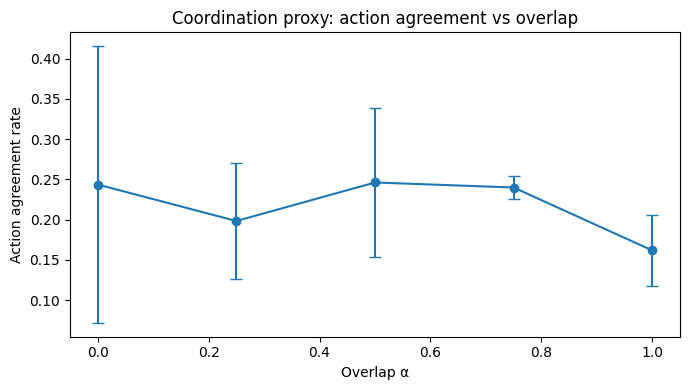

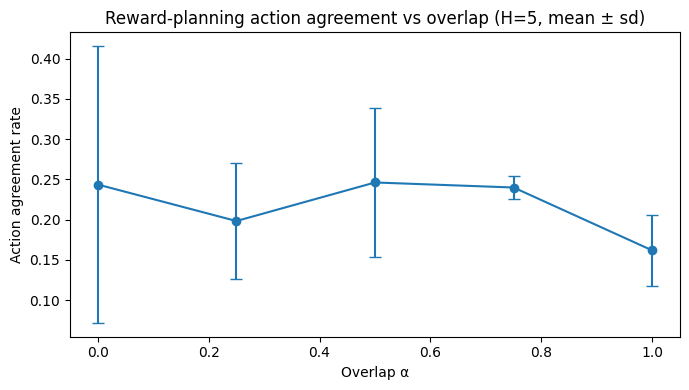

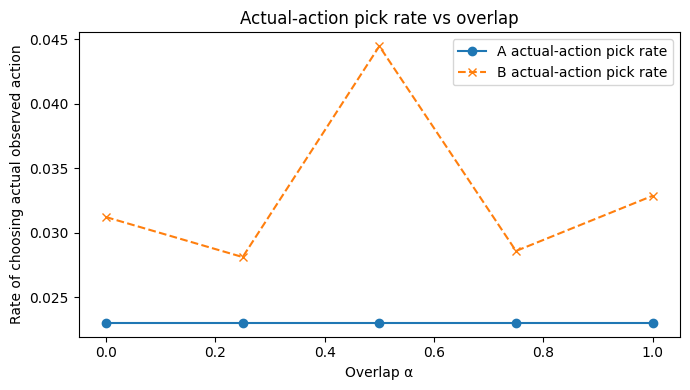

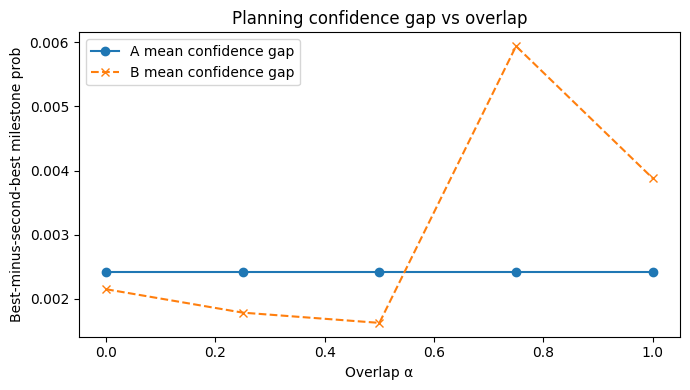

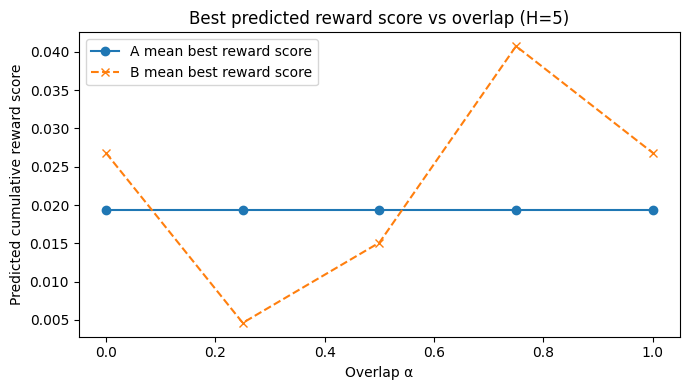

In [ ]:
# Cell 15: Plot 1 — action agreement vs overlap

plt.figure(figsize=(7, 4))

alphas_sorted = sorted(set(float(r["requested_alpha"]) for r in action_results["runs"]))
means = []
stds = []

for alpha in alphas_sorted:
    vals = [
        float(r["metrics"]["action_agreement_rate"])
        for r in action_results["runs"]
        if float(r["requested_alpha"]) == alpha
    ]
    means.append(np.mean(vals))
    stds.append(np.std(vals, ddof=1) if len(vals) > 1 else 0.0)

plt.errorbar(alphas_sorted, means, yerr=stds, marker="o", capsize=4)
plt.xlabel("Overlap α")
plt.ylabel("Action agreement rate")
plt.title("Coordination proxy: action agreement vs overlap")
plt.tight_layout()
plt.show()



# Cell 16b: Action agreement vs overlap (mean ± sd)

plt.figure(figsize=(7, 4))

alphas_sorted = sorted(set(float(r["requested_alpha"]) for r in action_results["runs"]))
means = []
stds = []

for alpha in alphas_sorted:
    vals = [
        float(r["metrics"]["action_agreement_rate"])
        for r in action_results["runs"]
        if float(r["requested_alpha"]) == alpha
    ]
    means.append(np.mean(vals))
    stds.append(np.std(vals, ddof=1) if len(vals) > 1 else 0.0)

plt.errorbar(alphas_sorted, means, yerr=stds, marker="o", capsize=4)
plt.xlabel("Overlap α")
plt.ylabel("Action agreement rate")
plt.title(f"Reward-planning action agreement vs overlap (H={PLAN_HORIZON}, mean ± sd)")
plt.tight_layout()
plt.show()



# Cell 16: Plot 2 — actual-action pick rate vs overlap

plt.figure(figsize=(7, 4))

A_means, B_means = [], []
for alpha in alphas_sorted:
    A_vals = [
        float(r["metrics"]["A_actual_action_pick_rate"])
        for r in action_results["runs"]
        if float(r["requested_alpha"]) == alpha
    ]
    B_vals = [
        float(r["metrics"]["B_actual_action_pick_rate"])
        for r in action_results["runs"]
        if float(r["requested_alpha"]) == alpha
    ]
    A_means.append(np.mean(A_vals))
    B_means.append(np.mean(B_vals))

plt.plot(alphas_sorted, A_means, marker="o", label="A actual-action pick rate")
plt.plot(alphas_sorted, B_means, marker="x", linestyle="--", label="B actual-action pick rate")
plt.xlabel("Overlap α")
plt.ylabel("Rate of choosing actual observed action")
plt.title("Actual-action pick rate vs overlap")
plt.legend()
plt.tight_layout()
plt.show()



# Cell 17: Plot 3 — confidence gap vs overlap

plt.figure(figsize=(7, 4))

A_gap_means, B_gap_means = [], []
for alpha in alphas_sorted:
    A_vals = [
        float(r["metrics"]["A_mean_confidence_gap"])
        for r in action_results["runs"]
        if float(r["requested_alpha"]) == alpha
    ]
    B_vals = [
        float(r["metrics"]["B_mean_confidence_gap"])
        for r in action_results["runs"]
        if float(r["requested_alpha"]) == alpha
    ]
    A_gap_means.append(np.mean(A_vals))
    B_gap_means.append(np.mean(B_vals))

plt.plot(alphas_sorted, A_gap_means, marker="o", label="A mean confidence gap")
plt.plot(alphas_sorted, B_gap_means, marker="x", linestyle="--", label="B mean confidence gap")
plt.xlabel("Overlap α")
plt.ylabel("Best-minus-second-best milestone prob")
plt.title("Planning confidence gap vs overlap")
plt.legend()
plt.tight_layout()
plt.show()


# Cell 17b: Best reward score vs overlap

plt.figure(figsize=(7, 4))

A_score_means, B_score_means = [], []
for alpha in alphas_sorted:
    A_vals = [
        float(r["metrics"]["A_mean_best_score"])
        for r in action_results["runs"]
        if float(r["requested_alpha"]) == alpha
    ]
    B_vals = [
        float(r["metrics"]["B_mean_best_score"])
        for r in action_results["runs"]
        if float(r["requested_alpha"]) == alpha
    ]
    A_score_means.append(np.mean(A_vals))
    B_score_means.append(np.mean(B_vals))

plt.plot(alphas_sorted, A_score_means, marker="o", label="A mean best reward score")
plt.plot(alphas_sorted, B_score_means, marker="x", linestyle="--", label="B mean best reward score")
plt.xlabel("Overlap α")
plt.ylabel("Predicted cumulative reward score")
plt.title(f"Best predicted reward score vs overlap (H={PLAN_HORIZON})")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Cell 18: Sanity check — exact inventory

ALPHAS = [0.0, 0.25, 0.50, 0.75, 1.0]
SEEDS = [1337, 1338, 1339]

expected_pairs = {(float(a), int(s)) for a in ALPHAS for s in SEEDS}
found_pairs = {(float(r["requested_alpha"]), int(r["seed"])) for r in action_results["runs"]}

missing = expected_pairs - found_pairs
extra = found_pairs - expected_pairs

print("Missing pairs:", missing)
print("Extra pairs:", extra)

assert len(missing) == 0, f"Missing run pairs: {missing}"
assert len(extra) == 0, f"Unexpected run pairs: {extra}"
print("Run inventory check passed.")

Missing pairs: set()
Extra pairs: set()
Run inventory check passed.


In [ ]:
# Cell 19: Sanity check — numeric validity

def is_bad_number(x):
    return (x is None) or (isinstance(x, float) and (math.isnan(x) or math.isinf(x)))

bad = []
for run in action_results["runs"]:
    alpha = run["requested_alpha"]
    seed = run["seed"]
    m = run["metrics"]

    # Rates must lie in [0, 1]
    for k in [
        "action_agreement_rate",
        "A_actual_action_pick_rate",
        "B_actual_action_pick_rate",
    ]:
        v = float(m[k])
        if is_bad_number(v) or v < 0.0 or v > 1.0:
            bad.append((alpha, seed, k, v))

    # Confidence gaps must be finite and nonnegative
    for k in [
        "A_mean_confidence_gap",
        "B_mean_confidence_gap",
    ]:
        v = float(m[k])
        if is_bad_number(v) or v < 0.0:
            bad.append((alpha, seed, k, v))

    # Best scores only need to be finite; they may be negative
    for k in [
        "A_mean_best_score",
        "B_mean_best_score",
    ]:
        v = float(m[k])
        if is_bad_number(v):
            bad.append((alpha, seed, k, v))

    # Count must be positive
    if int(m["n"]) <= 0:
        bad.append((alpha, seed, "n", m["n"]))

if len(bad) == 0:
    print("Numeric sanity check passed.")
else:
    print("Found bad values:")
    for x in bad:
        print(x)
    raise ValueError("Numeric sanity check failed.")

Numeric sanity check passed.
